In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import mode
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support
# Set plot style for better aesthetics
sns.set_style("whitegrid")
print("All libraries imported successfully.")


All libraries imported successfully.


In [2]:
def preprocess_data(train_df, test_df):
    """Preprocesses training and testing dataframes, handling NaNs, scaling, and encoding."""
    # Separate target variable and drop ID column
    X_train_full = train_df.drop(['ID', 'Segmentation'], axis=1)
    y_train_full = train_df['Segmentation']
    X_test_final = test_df.drop('ID', axis=1)

    # Define preprocessing pipelines for numerical and categorical features
    numerical_features = X_train_full.select_dtypes(include=np.number).columns.tolist()
    numerical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_features = X_train_full.select_dtypes(exclude=np.number).columns.tolist()
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    # Create the master preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='passthrough'
    )

    # Fit on the full training data and transform all datasets
    preprocessor.fit(X_train_full)
    X_train_full_processed = preprocessor.transform(X_train_full)
    X_test_processed = preprocessor.transform(X_test_final)

    print("Data preprocessing complete.")
    return X_train_full_processed, y_train_full, X_test_processed, preprocessor


In [ ]:
class MyRandomForestClassifier:
    """A Random Forest classifier implemented from scratch using Decision Trees."""
    def __init__(self, n_estimators=100, max_features='sqrt', random_state=42):
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.random_state = random_state
        self.trees_ = []
        self.class_mapping_ = {}
        self.reverse_class_mapping_ = {}

    def fit(self, X, y):
        """Trains n_estimators Decision Trees on bootstrap samples of the data."""
        self.trees_ = []
        n_samples, n_features = X.shape
        
        if not isinstance(y, np.ndarray):
            y = y.to_numpy()

        unique_classes = np.unique(y)
        self.class_mapping_ = {label: i for i, label in enumerate(unique_classes)}
        self.reverse_class_mapping_ = {i: label for label, i in self.class_mapping_.items()}
        y_mapped = np.array([self.class_mapping_[label] for label in y])

        rng = np.random.RandomState(self.random_state)
        
        for _ in range(self.n_estimators):
            bootstrap_indices = rng.choice(n_samples, size=n_samples, replace=True)
            X_sample, y_sample_mapped = X[bootstrap_indices], y_mapped[bootstrap_indices]
            
            tree = DecisionTreeClassifier(
                max_features=self.max_features, 
                random_state=rng.randint(0, 10000),
                class_weight='balanced'
            )
            tree.fit(X_sample, y_sample_mapped)
            self.trees_.append(tree)
        return self

    def predict(self, X):
        """Makes predictions using a majority vote from all trained trees."""
        tree_predictions = np.array([tree.predict(X) for tree in self.trees_])
        tree_predictions = np.swapaxes(tree_predictions, 0, 1)
        
        
        final_predictions_mapped = []
        for row in tree_predictions:
            values, counts = np.unique(row, return_counts=True)
            most_common_class = values[np.argmax(counts)]
            final_predictions_mapped.append(most_common_class)
        
        final_predictions_mapped = np.array(final_predictions_mapped)
        
        
        final_labels = np.array([
            self.reverse_class_mapping_[pred] for pred in final_predictions_mapped
        ])
        return final_labels

Files loaded successfully.


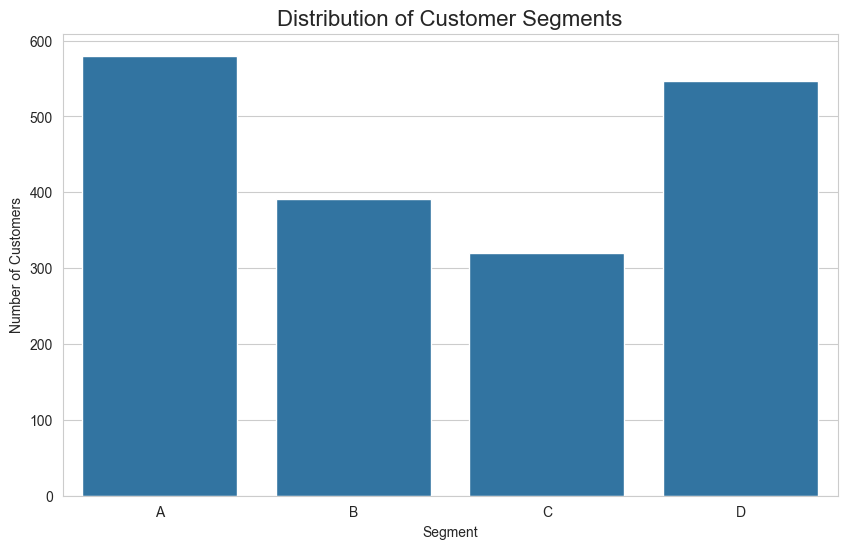

In [4]:
# Load the datasets
try:
    train_df = pd.read_csv('Customer_train.csv')
    test_df = pd.read_csv('Customer_test.csv')
    print("Files loaded successfully.")
except FileNotFoundError as e:
    print(f"Error: {e}. Make sure 'train.csv' and 'test.csv' are in the same directory.")

# --- New Plot 1: Class Distribution ---
plt.figure(figsize=(10, 6))
sns.countplot(x='Segmentation', data=train_df, order=sorted(train_df['Segmentation'].unique()))
plt.title('Distribution of Customer Segments', fontsize=16)
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.show()


Data preprocessing complete.

--- Testing different numbers of trees (n) ---
Validation Accuracy for n=1: 0.2582
Validation Accuracy for n=5: 0.3098
Validation Accuracy for n=10: 0.2989
Validation Accuracy for n=15: 0.3125
Validation Accuracy for n=20: 0.3179
Validation Accuracy for n=25: 0.3179
Validation Accuracy for n=30: 0.3016
Validation Accuracy for n=35: 0.2962
Validation Accuracy for n=40: 0.2962
Validation Accuracy for n=45: 0.2962
Validation Accuracy for n=50: 0.2989
Validation Accuracy for n=55: 0.2962
Validation Accuracy for n=60: 0.2826
Validation Accuracy for n=65: 0.2745
Validation Accuracy for n=70: 0.2799
Validation Accuracy for n=75: 0.2908
Validation Accuracy for n=80: 0.2962
Validation Accuracy for n=85: 0.2880
Validation Accuracy for n=90: 0.2989
Validation Accuracy for n=95: 0.2962
Validation Accuracy for n=100: 0.2935
Validation Accuracy for n=150: 0.2880
Validation Accuracy for n=200: 0.2908

Best performance achieved with n = 20 trees.


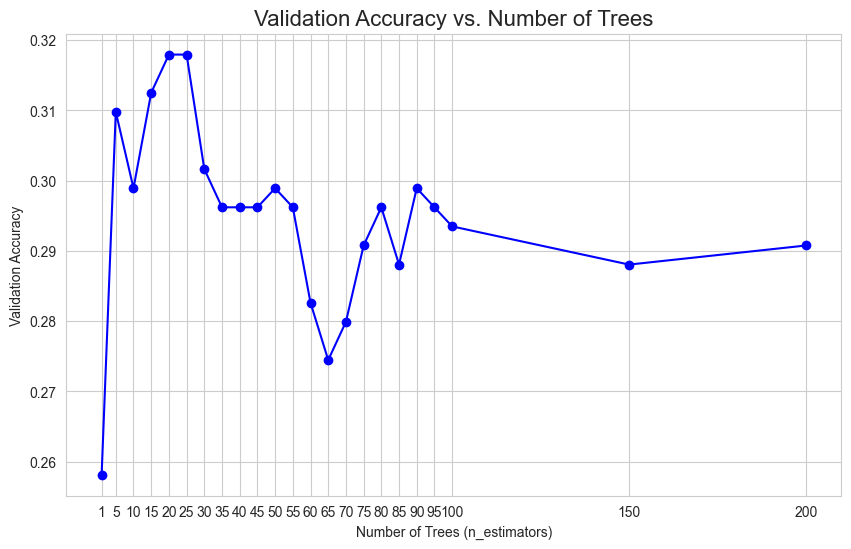

In [6]:
# Preprocess the data
X_full, y_full, X_test_final, preprocessor = preprocess_data(train_df, test_df)

# Create a validation split from the training data
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

# --- Test different values of n and find the best one ---
n_values = [1,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100, 150, 200]
accuracy_scores = []

print("\n--- Testing different numbers of trees (n) ---")
for n in n_values:
    rf_validator = MyRandomForestClassifier(n_estimators=n, random_state=42)
    rf_validator.fit(X_train, y_train)
    y_pred_val = rf_validator.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred_val)
    accuracy_scores.append(accuracy)
    print(f"Validation Accuracy for n={n}: {accuracy:.4f}")

best_n = n_values[np.argmax(accuracy_scores)]
print(f"\nBest performance achieved with n = {best_n} trees.")

# --- New Plot 2: Validation Curve ---
plt.figure(figsize=(10, 6))
plt.plot(n_values, accuracy_scores, marker='o', linestyle='-', color='b')
plt.title('Validation Accuracy vs. Number of Trees', fontsize=16)
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Validation Accuracy')
plt.xticks(n_values)
plt.grid(True)
plt.show()



--- Evaluating the best model (n=20) on the validation set ---
Final Validation Accuracy: 0.3179

Detailed Metrics by Class:
  Class  Precision    Recall  F1-Score  Support
0     A   0.330935  0.396552  0.360784      116
1     B   0.250000  0.243590  0.246753       78
2     C   0.264151  0.218750  0.239316       64
3     D   0.380000  0.345455  0.361905      110

Confusion Matrix:


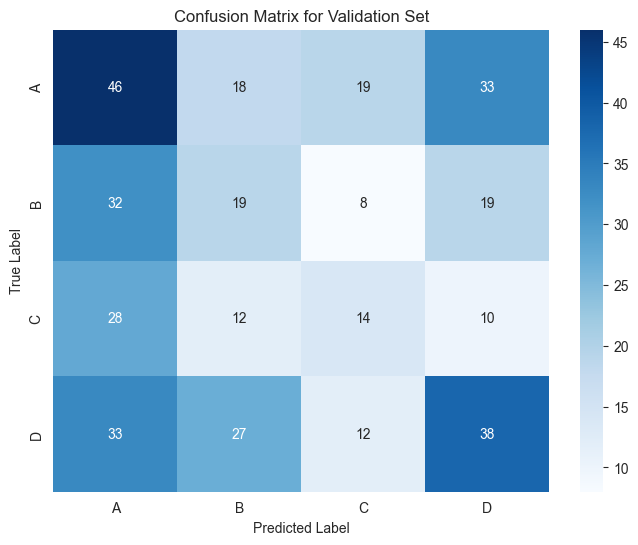

In [ ]:
print(f"\n--- Evaluating the best model (n={best_n}) on the validation set ---")
best_rf = MyRandomForestClassifier(n_estimators=best_n, random_state=42)
best_rf.fit(X_train, y_train)
y_pred_best = best_rf.predict(X_val)
print(f"Final Validation Accuracy: {accuracy_score(y_val, y_pred_best):.4f}\n")


unique_labels = sorted(y_full.unique())
precision, recall, f1, support = precision_recall_fscore_support(
    y_val, y_pred_best, labels=unique_labels
)
metrics_df = pd.DataFrame({
    'Class': unique_labels,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})
print("Detailed Metrics by Class:")
print(metrics_df)

print("\nConfusion Matrix:")
cm = confusion_matrix(y_val, y_pred_best, labels=unique_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Validation Set')
plt.show()



--- Training final model on ALL training data ---


C:\Users\sanke\AppData\Local\Temp\ipykernel_22632\1760078709.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(15), palette='viridis')


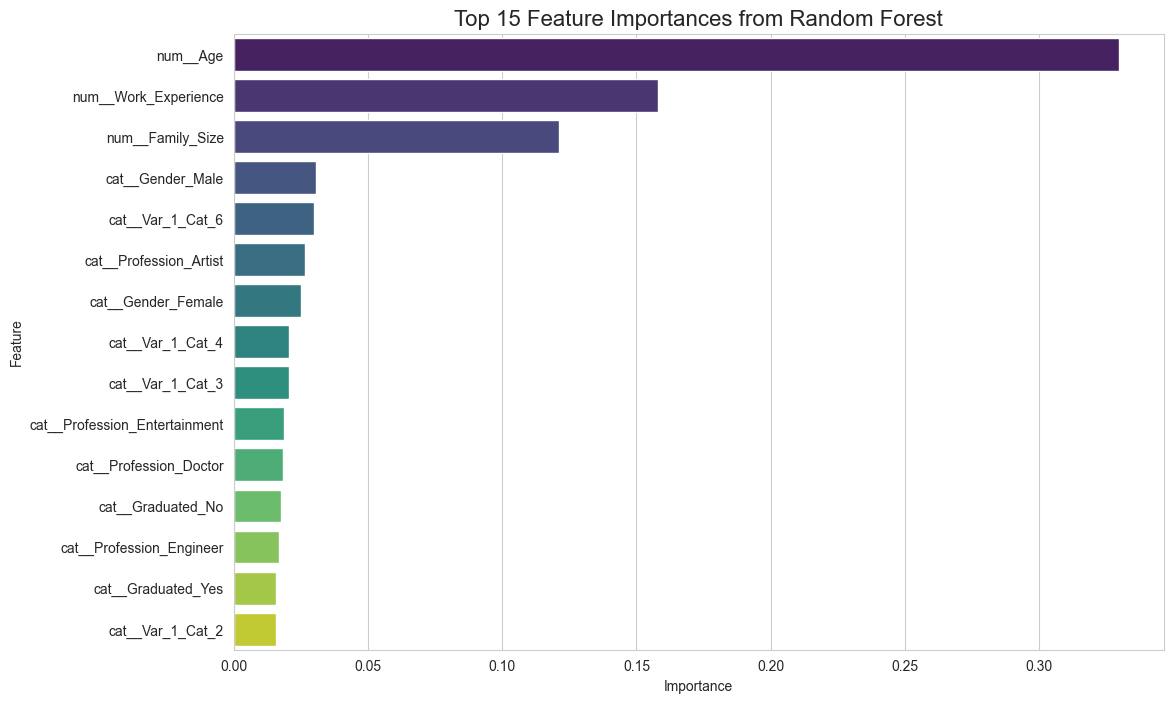

In [ ]:
print("\n--- Training final model on ALL training data ---")
final_model = MyRandomForestClassifier(n_estimators=best_n, random_state=42)
final_model.fit(X_full, y_full)


all_feature_names = preprocessor.get_feature_names_out()
importances = np.mean([tree.feature_importances_ for tree in final_model.trees_], axis=0)
feature_importance_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances from Random Forest', fontsize=16)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


In [8]:
print("\n--- Predicting on the official test set (test.csv) ---")

# Make predictions on the preprocessed test data
test_predictions = final_model.predict(X_test_final)

# Create a DataFrame for a clean view of the predictions
predictions_df = pd.DataFrame({
    'ID': test_df['ID'],
    'Predicted_Segmentation': test_predictions
})

print("\nFinal Predicted Output for test.csv:")
print(predictions_df)

print(f"\nFirst 20 predictions for the test dataset:")
print(test_predictions[:20])



--- Predicting on the official test set (test.csv) ---

Final Predicted Output for test.csv:
         ID Predicted_Segmentation
0    459678                      B
1    460051                      A
2    462094                      B
3    467493                      D
4    463766                      A
..      ...                    ...
784  463588                      D
785  464593                      C
786  463470                      B
787  461078                      A
788  466905                      D

[789 rows x 2 columns]

First 20 predictions for the test dataset:
['B' 'A' 'B' 'D' 'A' 'A' 'D' 'A' 'A' 'B' 'B' 'C' 'D' 'A' 'D' 'A' 'C' 'D'
 'A' 'A']
